#  LoRA vs Full Fine-Tuning on SST-2
### Replicating *LoRA: Low-Rank Adaptation of Large Language Models* — Hu et al., 2021

**Model :** RoBERTa-base (125 M parameters)  
**Task  :** SST-2 Binary Sentiment Classification (GLUE)  
**Stack :** HuggingFace `transformers` + `peft` + `datasets`

| | Full Fine-Tuning | LoRA |
|---|---|---|
| What is trained | All weights | Low-rank matrices A, B only |
| GPU memory | High | Reduced |
| Inference latency | Baseline | **Identical** (weights merged) |
| Storage per task | Full model copy | Tiny adapter (~35 MB) |

**Key equation:** `h = W₀x + BAx`  where  `B ∈ ℝᵈˣʳ`,  `A ∈ ℝʳˣᵏ`,  `r ≪ d`

## 1 · Setup

In [1]:
# Install all required packages — run once per session
!pip install transformers peft datasets accelerate evaluate scikit-learn -q
!pip install torchao --upgrade -q
print('Installation complete.')

Installation complete.


In [2]:
!pip install torchao --upgrade -q

In [3]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset
import evaluate

warnings.filterwarnings('ignore')
os.makedirs('./results', exist_ok=True)
print('All libraries imported.')

Failed to load /home/nj349/.local/lib/python3.12/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /mmfs1/home/nj349/.local/lib/python3.12/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so


Failed to load /home/nj349/.local/lib/python3.12/site-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /mmfs1/home/nj349/.local/lib/python3.12/site-packages/torchao/_C_cutlass_90a.abi3.so


All libraries imported.


## 2 · Configuration

In [4]:
# ── All hyperparameters live here ─────────────────────────────────────────────
CONFIG = {
    # Model & task
    'model_name'   : 'roberta-base',
    'num_labels'   : 2,

    # Data
    'dataset'      : 'sst2',
    'max_length'   : 128,
    'train_subset' : None,   # set to None to use full ~67 k training set

    # Training
    'epochs'       : 3,
    'batch_size'   : 32,
    'lr'           : 2e-5,
    'weight_decay' : 0.01,
    'seed'         : 42,

    # LoRA
    'lora_r'       : 8,
    'lora_alpha'   : 16,        # scaling = lora_alpha / r
    'lora_dropout' : 0.1,
    'lora_targets' : ['query', 'value'],   # attention projection matrices
}

set_seed(CONFIG['seed'])
print('CONFIG:')
for k, v in CONFIG.items():
    print(f'  {k:<18}: {v}')

CONFIG:
  model_name        : roberta-base
  num_labels        : 2
  dataset           : sst2
  max_length        : 128
  train_subset      : None
  epochs            : 3
  batch_size        : 32
  lr                : 2e-05
  weight_decay      : 0.01
  seed              : 42
  lora_r            : 8
  lora_alpha        : 16
  lora_dropout      : 0.1
  lora_targets      : ['query', 'value']


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM   : {vram:.2f} GB')
else:
    print('WARNING: No GPU detected — training will be slow on CPU.')

Device : cuda
GPU    : NVIDIA A100-PCIE-40GB MIG 2g.10gb
VRAM   : 9.75 GB


## 3 · Data Loading & Tokenization

In [6]:
raw = load_dataset('glue', 'sst2')

# Optionally subset training set for faster iteration
train_data = raw['train']
if CONFIG['train_subset']:
    train_data = train_data.select(range(CONFIG['train_subset']))
val_data = raw['validation']

print(f'Train : {len(train_data):,} examples')
print(f'Val   : {len(val_data):,} examples')
print(f'\nSample: {train_data[0]}')

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train : 67,349 examples
Val   : 872 examples

Sample: {'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


In [7]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

def tokenize_fn(batch):
    return tokenizer(
        batch['sentence'],
        truncation=True,
        max_length=CONFIG['max_length'],
        padding=False,          # dynamic padding via DataCollatorWithPadding
    )

def prepare(ds):
    ds = ds.map(tokenize_fn, batched=True, remove_columns=['sentence', 'idx'])
    ds = ds.rename_column('label', 'labels')
    ds.set_format('torch')
    return ds

train_ds = prepare(train_data)
val_ds   = prepare(val_data)

print('Tokenization complete.')
print(f'Features : {list(train_ds.features.keys())}')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Tokenization complete.
Features : ['labels', 'input_ids', 'attention_mask']


## 4 · Helper Functions

In [8]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
glue_metric   = evaluate.load('glue', 'sst2')

# ── Parameter counting ────────────────────────────────────────────────────────
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# ── Metric computation ────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return glue_metric.compute(predictions=preds, references=labels)

# ── Training arguments factory ────────────────────────────────────────────────
def get_args(output_dir, epochs=None):
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = epochs if epochs else CONFIG['epochs'],
        per_device_train_batch_size = CONFIG['batch_size'],
        per_device_eval_batch_size  = CONFIG['batch_size'] * 2,
        learning_rate               = CONFIG['lr'],
        weight_decay                = CONFIG['weight_decay'],
        eval_strategy                       = 'epoch',
        save_strategy               = 'no',
        fp16                        = torch.cuda.is_available(),
        seed                        = CONFIG['seed'],
        report_to                   = 'none',
        logging_steps               = 100,
    )

# ── Single experiment runner ──────────────────────────────────────────────────
def run_experiment(model, output_dir, epochs=None):
    '''Train model and return (val_accuracy, peak_mem_GB, elapsed_seconds).'''
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    trainer = Trainer(
        model           = model,
        args            = get_args(output_dir, epochs),
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        data_collator   = data_collator,
        compute_metrics = compute_metrics,
    )

    t0      = time.time()
    trainer.train()
    elapsed = time.time() - t0

    peak_mem = (torch.cuda.max_memory_allocated() / 1024**3
                if torch.cuda.is_available() else 0.0)
    accuracy = trainer.evaluate()['eval_accuracy']
    return accuracy, peak_mem, elapsed

print('Helpers defined.')

Helpers defined.


## 5 · Experiment 1 — Full Fine-Tuning

Standard fine-tuning updates **all** 125 M parameters.
Every weight in the model receives gradient updates at each step.
This is our performance and memory **baseline**.

In [9]:
ft_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
)
ft_total, ft_trainable = count_parameters(ft_model)

print(f'{"Total Parameters":<25}: {ft_total:>15,}')
print(f'{"Trainable Parameters":<25}: {ft_trainable:>15,}')
print(f'{"Trainable %":<25}: {100 * ft_trainable / ft_total:>14.2f}%')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Parameters         :     124,647,170
Trainable Parameters     :     124,647,170
Trainable %              :         100.00%


In [10]:
print('Training Full Fine-Tuning model...\n')

ft_acc, ft_mem, ft_time = run_experiment(ft_model, './results/full_ft')

print(f'\n{"─"*45}')
print(f'  Validation Accuracy : {ft_acc:.4f}')
print(f'  Peak GPU Memory     : {ft_mem:.3f} GB')
print(f'  Training Time       : {ft_time:.0f}s  ({ft_time/60:.1f} min)')
print(f'{"─"*45}')

# Free GPU memory before next experiment
del ft_model
torch.cuda.empty_cache()

Training Full Fine-Tuning model...



Epoch,Training Loss,Validation Loss,Accuracy
1,0.188603,0.181235,0.939220
2,0.123791,0.243180,0.943807
3,0.096027,0.256641,0.942661


Training Loss,Validation Loss,Epoch,Accuracy
0.096027,0.256641,3,0.942661



─────────────────────────────────────────────
  Validation Accuracy : 0.9427
  Peak GPU Memory     : 2.437 GB
  Training Time       : 368s  (6.1 min)
─────────────────────────────────────────────


## 6 · Experiment 2 — LoRA Fine-Tuning

LoRA **freezes** the pretrained weights `W₀` and injects trainable  
rank decomposition matrices in parallel:

```
h = W₀x + ΔWx = W₀x + BAx
```

- **A** ∈ ℝʳˣᵏ — initialized with random Gaussian → non-zero gradient from step 1  
- **B** ∈ ℝᵈˣʳ — initialized to **zero** → ΔW = BA = 0 at start of training  
- Only the attention `query` and `value` projections are targeted  
- At inference: merge `W = W₀ + BA` → **zero added latency**

In [11]:
lora_base = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
)

lora_config = LoraConfig(
    task_type       = TaskType.SEQ_CLS,
    r               = CONFIG['lora_r'],
    lora_alpha      = CONFIG['lora_alpha'],
    target_modules  = CONFIG['lora_targets'],   # Wq and Wv in all 12 layers
    lora_dropout    = CONFIG['lora_dropout'],
    bias            = 'none',
    modules_to_save = ['classifier'],            # keep classifier head trainable
)

lora_model = get_peft_model(lora_base, lora_config)
lora_model.print_trainable_parameters()

lora_total, lora_trainable = count_parameters(lora_model)
print(f'\n{"Total Parameters":<25}: {lora_total:>15,}')
print(f'{"Trainable Parameters":<25}: {lora_trainable:>15,}')
print(f'{"Trainable %":<25}: {100 * lora_trainable / lora_total:>14.2f}%')
print(f'\nParameter reduction vs Full FT : {ft_trainable / lora_trainable:.0f}x fewer trainable params')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066

Total Parameters         :     125,534,212
Trainable Parameters     :         887,042
Trainable %              :           0.71%

Parameter reduction vs Full FT : 141x fewer trainable params


In [12]:
print('Training LoRA model...\n')

lora_acc, lora_mem, lora_time = run_experiment(lora_model, './results/lora')

print(f'\n{"─"*45}')
print(f'  Validation Accuracy : {lora_acc:.4f}')
print(f'  Peak GPU Memory     : {lora_mem:.3f} GB')
print(f'  Training Time       : {lora_time:.0f}s  ({lora_time/60:.1f} min)')
print(f'{"─"*45}')

del lora_model, lora_base
torch.cuda.empty_cache()

Training LoRA model...



[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.264253,0.211133,0.920872
2,0.238415,0.215565,0.919725
3,0.232080,0.206958,0.920872


Training Loss,Validation Loss,Epoch,Accuracy
0.232080,0.206958,3,0.920872



─────────────────────────────────────────────
  Validation Accuracy : 0.9209
  Peak GPU Memory     : 1.889 GB
  Training Time       : 289s  (4.8 min)
─────────────────────────────────────────────


## 7 · Rank Ablation Study

Replicating **Table 6** from the paper.

We sweep `r ∈ {1, 2, 4, 8, 16}` and measure accuracy, parameter count, and memory.  
The paper's key finding: *a rank as small as 1 suffices*, suggesting weight updates  
have a very low **intrinsic rank**.

> *"The update matrix ΔW could have a very small intrinsic rank."* — Hu et al., 2021

In [13]:
RANKS  = [1, 2, 4, 8, 16]
EPOCHS = 3                    # 2 epochs to save time during ablation
abl    = []

print(f'Ablation: r in {RANKS}, {EPOCHS} epochs each\n')

for r in RANKS:
    print(f'  ── r = {r} ' + '─'*30)
    base = AutoModelForSequenceClassification.from_pretrained(
        CONFIG['model_name'], num_labels=CONFIG['num_labels'],
    )
    cfg = LoraConfig(
        task_type       = TaskType.SEQ_CLS,
        r               = r,
        lora_alpha      = r * 2,             # keep alpha / r ratio constant
        target_modules  = CONFIG['lora_targets'],
        lora_dropout    = CONFIG['lora_dropout'],
        bias            = 'none',
        modules_to_save = ['classifier'],
    )
    m           = get_peft_model(base, cfg)
    _, n_params = count_parameters(m)
    acc, mem, t = run_experiment(m, f'./results/lora_r{r}', epochs=EPOCHS)

    abl.append({
        'rank'     : r,
        'params_k' : round(n_params / 1_000, 1),
        'accuracy' : acc,
        'mem_gb'   : round(mem, 3),
        'time_min' : round(t / 60, 1),
    })
    print(f'  acc={acc:.4f}  params={n_params:,}  mem={mem:.2f} GB\n')

    del m, base
    torch.cuda.empty_cache()

abl_df = pd.DataFrame(abl)
print('\nRank Ablation Results:')
print(abl_df.to_string(index=False))

Ablation: r in [1, 2, 4, 8, 16], 3 epochs each

  ── r = 1 ──────────────────────────────


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.310203,0.241456,0.903670
2,0.270445,0.228497,0.909404
3,0.256022,0.224399,0.913991


Training Loss,Validation Loss,Epoch,Accuracy
0.256022,0.224399,3,0.913991


...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.252231,0.209661,0.920872
2,0.227992,0.211821,0.922018
3,0.221325,0.201736,0.926606


Training Loss,Validation Loss,Epoch,Accuracy
0.221325,0.201736,3,0.926606


  acc=0.9266  params=1,181,954  mem=1.31 GB


Rank Ablation Results:


 rank  params_k  accuracy  mem_gb  time_min
    1     629.0  0.913991   1.298       4.6
    2     665.9  0.917431   1.298       4.6
    4     739.6  0.919725   1.301       4.6
    8     887.0  0.920872   1.300       4.5
   16    1182.0  0.926606   1.310       4.5


## 8 · Results & Analysis

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Method'           : ['Full Fine-Tuning', f'LoRA (r={CONFIG["lora_r"]})'],
    'Trainable Params' : [f'{ft_trainable:,}', f'{lora_trainable:,}'],
    'Trainable %'      : [f'{100*ft_trainable/ft_total:.2f}%',
                          f'{100*lora_trainable/lora_total:.2f}%'],
    'Peak Mem (GB)'    : [f'{ft_mem:.3f}', f'{lora_mem:.3f}'],
    'Train Time (min)' : [f'{ft_time/60:.1f}', f'{lora_time/60:.1f}'],
    'Val Accuracy'     : [f'{ft_acc:.4f}', f'{lora_acc:.4f}'],
})

print('=' * 80)
print('                         RESULTS SUMMARY')
print('=' * 80)
print(summary.to_string(index=False))
print('=' * 80)

param_reduction = ft_trainable / lora_trainable
mem_saving      = (1 - lora_mem / ft_mem) * 100 if ft_mem > 0 else 0.0
acc_delta       = (lora_acc - ft_acc) * 100

print(f'\n  Parameter reduction : {param_reduction:.0f}x fewer trainable parameters')
print(f'  Memory savings      : {mem_saving:.1f}% less peak GPU memory')
print(f'  Accuracy delta      : {acc_delta:+.2f}% ({("better" if acc_delta >= 0 else "lower")})')

                         RESULTS SUMMARY
          Method Trainable Params Trainable % Peak Mem (GB) Train Time (min) Val Accuracy
Full Fine-Tuning      124,647,170     100.00%         2.437              6.1       0.9427
      LoRA (r=8)          887,042       0.71%         1.889              4.8       0.9209

  Parameter reduction : 141x fewer trainable parameters
  Memory savings      : 22.5% less peak GPU memory
  Accuracy delta      : -2.18% (lower)


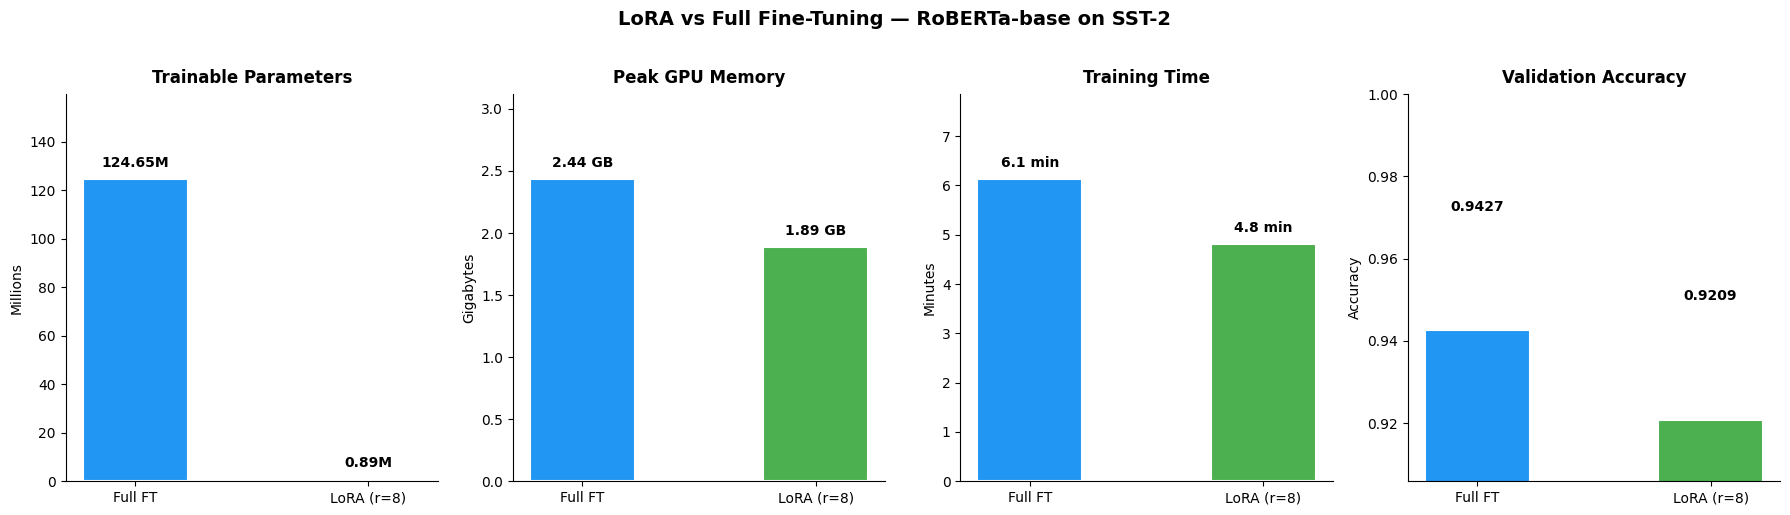

Saved: ./results/comparison.png


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('LoRA vs Full Fine-Tuning — RoBERTa-base on SST-2',
             fontsize=14, fontweight='bold', y=1.02)

labels = ['Full FT', f'LoRA (r={CONFIG["lora_r"]})']
colors = ['#2196F3', '#4CAF50']

def bar_chart(ax, title, ylabel, vals, fmt_fn, tight_ylim=False):
    bars = ax.bar(labels, vals, color=colors, width=0.45,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + max(vals) * 0.03, fmt_fn(v),
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    if tight_ylim:
        ax.set_ylim(min(vals) - 0.015, 1.0)
    else:
        ax.set_ylim(0, max(vals) * 1.28)

bar_chart(axes[0], 'Trainable Parameters', 'Millions',
          [ft_trainable / 1e6, lora_trainable / 1e6],
          lambda v: f'{v:.2f}M')

bar_chart(axes[1], 'Peak GPU Memory', 'Gigabytes',
          [ft_mem, lora_mem],
          lambda v: f'{v:.2f} GB')

bar_chart(axes[2], 'Training Time', 'Minutes',
          [ft_time / 60, lora_time / 60],
          lambda v: f'{v:.1f} min')

bar_chart(axes[3], 'Validation Accuracy', 'Accuracy',
          [ft_acc, lora_acc],
          lambda v: f'{v:.4f}',
          tight_ylim=True)

plt.tight_layout()
plt.savefig('./results/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./results/comparison.png')

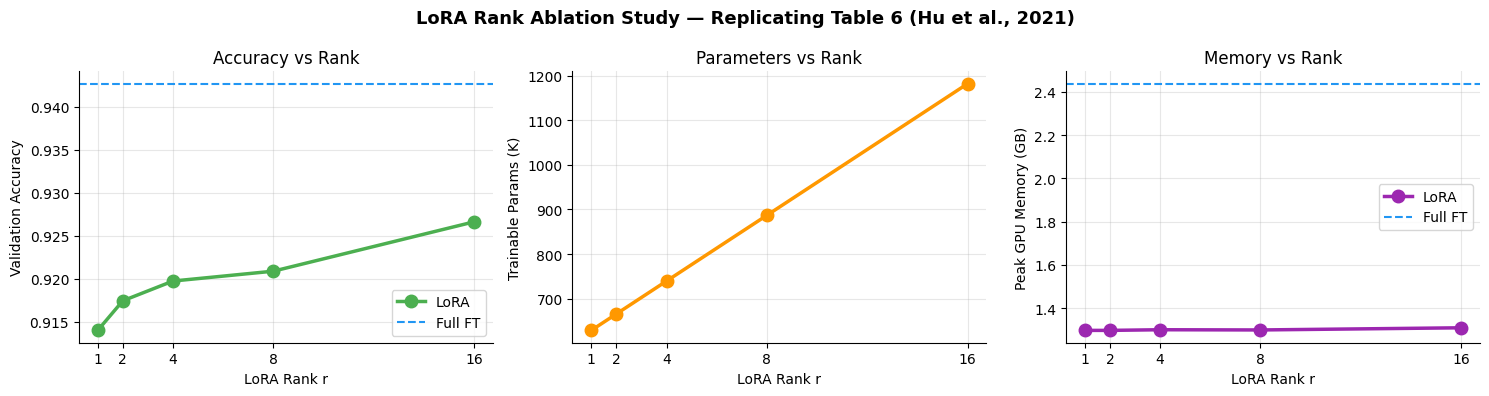

Saved: ./results/rank_ablation.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('LoRA Rank Ablation Study — Replicating Table 6 (Hu et al., 2021)',
             fontsize=13, fontweight='bold')

ranks = abl_df['rank'].tolist()
kw    = dict(marker='o', linewidth=2.5, markersize=9)

# Accuracy vs rank
axes[0].plot(ranks, abl_df['accuracy'], color='#4CAF50', **kw, label='LoRA')
axes[0].axhline(ft_acc, color='#2196F3', linestyle='--', linewidth=1.5, label='Full FT')
axes[0].set(xlabel='LoRA Rank r', ylabel='Validation Accuracy',
            title='Accuracy vs Rank')
axes[0].legend(); axes[0].set_xticks(ranks)

# Trainable parameters vs rank
axes[1].plot(ranks, abl_df['params_k'], color='#FF9800', **kw)
axes[1].set(xlabel='LoRA Rank r', ylabel='Trainable Params (K)',
            title='Parameters vs Rank')
axes[1].set_xticks(ranks)

# Memory vs rank
axes[2].plot(ranks, abl_df['mem_gb'], color='#9C27B0', **kw, label='LoRA')
axes[2].axhline(ft_mem, color='#2196F3', linestyle='--', linewidth=1.5, label='Full FT')
axes[2].set(xlabel='LoRA Rank r', ylabel='Peak GPU Memory (GB)',
            title='Memory vs Rank')
axes[2].legend(); axes[2].set_xticks(ranks)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/rank_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./results/rank_ablation.png')

## 9 · Save Results

In [17]:
# Save main comparison to CSV
main_df = pd.DataFrame({
    'method'           : ['Full_FT', f'LoRA_r{CONFIG["lora_r"]}'],
    'total_params'     : [ft_total,     lora_total],
    'trainable_params' : [ft_trainable, lora_trainable],
    'trainable_pct'    : [round(100 * ft_trainable / ft_total, 4),
                          round(100 * lora_trainable / lora_total, 4)],
    'peak_memory_gb'   : [round(ft_mem,  4), round(lora_mem,  4)],
    'train_time_s'     : [round(ft_time, 1), round(lora_time, 1)],
    'val_accuracy'     : [ft_acc, lora_acc],
})

main_df.to_csv('./results/main_results.csv', index=False)
abl_df.to_csv('./results/ablation_results.csv', index=False)

print('Results saved:')
print('  ./results/main_results.csv')
print('  ./results/ablation_results.csv')
print('  ./results/comparison.png')
print('  ./results/rank_ablation.png')
print()
print('All experiments complete.')
print(main_df.to_string(index=False))

Results saved:
  ./results/main_results.csv
  ./results/ablation_results.csv
  ./results/comparison.png
  ./results/rank_ablation.png

All experiments complete.
 method  total_params  trainable_params  trainable_pct  peak_memory_gb  train_time_s  val_accuracy
Full_FT     124647170         124647170       100.0000          2.4370         368.1      0.942661
LoRA_r8     125534212            887042         0.7066          1.8887         289.1      0.920872
